# Feature Engineering

1. Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

3. Load Dataset

In [4]:
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.shape

(1470, 35)

3. Remove Unnecessary Columns

In [6]:
df.drop(
    columns=[
        "EmployeeNumber",
        "EmployeeCount",
        "Over18",
        "StandardHours"
    ],
    inplace = True 
)

4. Encode Target

In [9]:
le = LabelEncoder()
df["Attrition"] = le.fit_transform(df["Attrition"])

In [10]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


5. Correlation Analysis

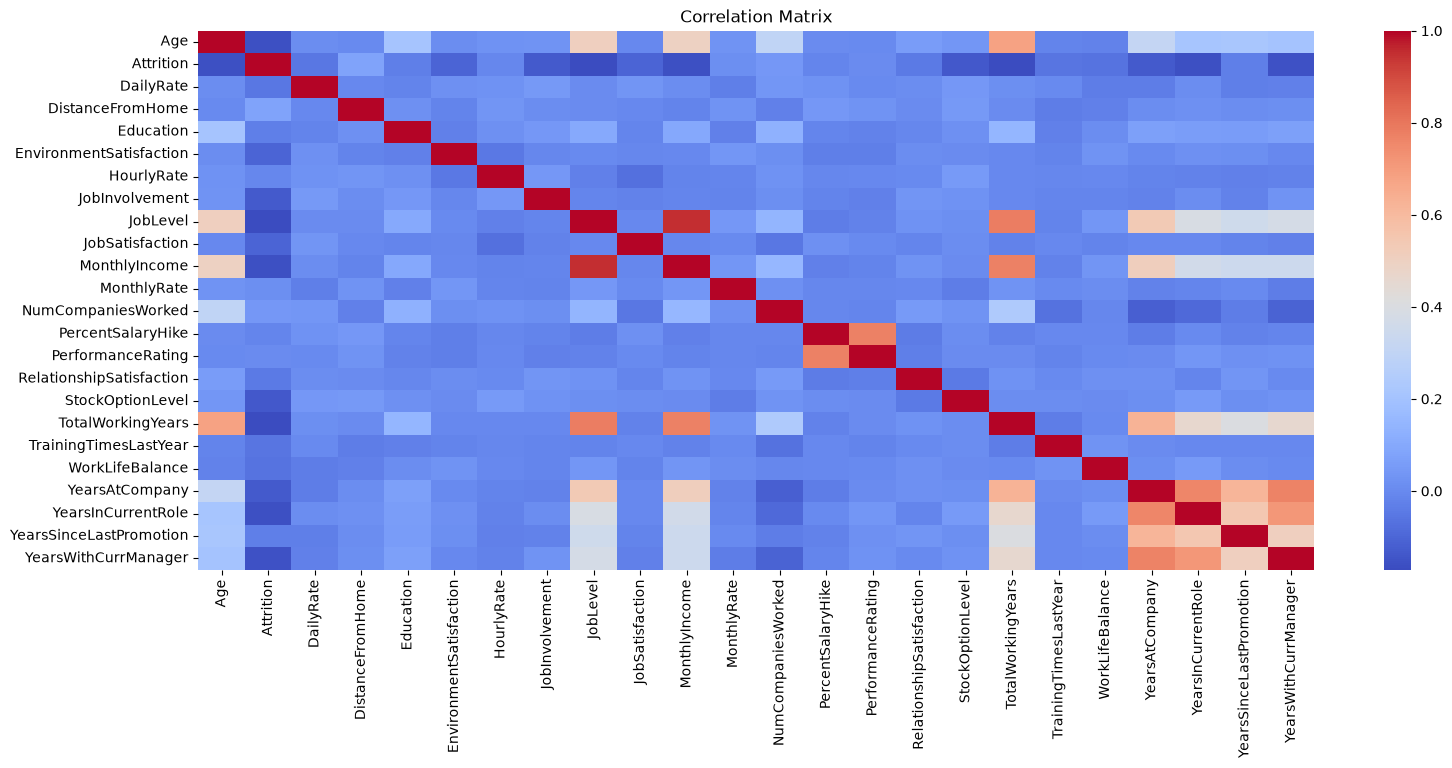

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,7))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

### Observation

1. Most numerical features show low to moderate correlation with each other.
2. The following feature pairs have relatively high positive correlation:
  - JobLevel and MonthlyIncome
  - TotalWorkingYears and MonthlyIncome
  - YearsAtCompany and YearsInCurrentRole
  - YearsAtCompany and YearsWithCurrManager
  - YearsInCurrentRole and YearsWithCurrManager
  - PercentSalaryHike and PerformanceRating
3. These correlations are expected because these features are logically related in the employee dataset.
4. No unexpected or excessive multicollinearity is observed at this stage.
5. Attrition does not have a strong linear correlation with any single numerical feature, suggesting that employee attrition is influenced by multiple factors rather than one numerical feature alone.

6. Check Feature Importance

In [12]:
x = df.drop("Attrition", axis = 1)
x = pd.get_dummies(x, drop_first=True)

y = df["Attrition"]

rf = RandomForestClassifier(
    random_state=42
)
rf.fit(x,y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [13]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(20)

,Feature,Importance
9,MonthlyIncome,0.071933
0,Age,0.060627
1,DailyRate,0.054689
43,OverTime_Yes,0.049590
16,TotalWorkingYears,0.048456
2,DistanceFromHome,0.047391
10,MonthlyRate,0.045867
5,HourlyRate,0.043808
19,YearsAtCompany,0.043172
12,PercentSalaryHike,0.033682


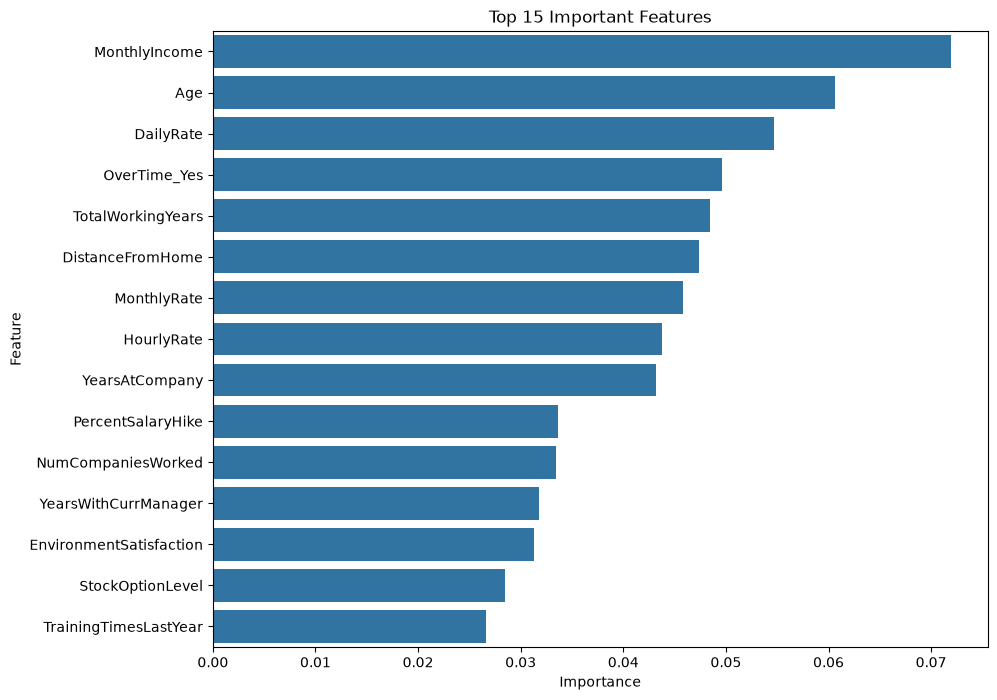

In [15]:
plt.figure(figsize=(10,8))

sns.barplot(
    data = importance.head(15),
    x = "Importance",
    y = "Feature"
)

plt.title("Top 15 Important Features")
plt.show()

### Feature Importance Analysis

1. MonthlyIncome is the most important feature, indicating that salary plays a major role in predicting employee attrition.
2. Age, DailyRate, OverTime_Yes, and TotalWorkingYears are also strong predictors.
3. Compensation-related features (MonthlyIncome, DailyRate, MonthlyRate, HourlyRate) have high importance, suggesting employee pay significantly influences attrition.
4. TrainingTimesLastYear, StockOptionLevel, and EnvironmentSatisfaction have relatively lower importance among the top 15 features.
5. Low feature importance does not mean a feature is useless; it simply means the model relied on it less compared to other features.
6. No features were removed since the primary objective of this project is to understand feature importance and build a robust machine learning pipeline.

8. Check Class Distribution Again

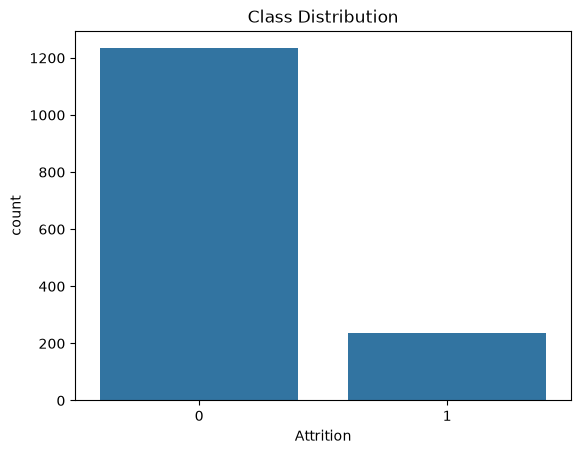

In [16]:
df["Attrition"].value_counts()

sns.countplot(
    x=df["Attrition"]
)
plt.title("Class Distribution")
plt.show()

### Key Points
1. Attrition is **not evenly distributed**.
2. Most employees belong to the **'No' (Stayed)** class, while relatively few belong to the **'Yes' (Left)** class.
3. This indicates that the dataset is **imbalanced**.
4. During model evaluation, accuracy alone may not be sufficient, so metrics such as **Precision, Recall, and F1 Score** should also be considered.

10. Save the Final Dataset

In [18]:
df.to_csv(
    "../data/processed_attrition.csv",
    index=False
)

## Feature Engineering

### Objective
Prepared the dataset for model training by analyzing feature relationships and estimating feature importance.

### Tasks Performed
1. Removed unnecessary identifier and constant columns.
2. Encoded the target variable.
3. Performed correlation analysis on numerical features.
4. Used Random Forest to estimate feature importance.
5. Visualized the top contributing features.
6. Reviewed class distribution.
7. Saved the processed dataset for future model training.

### Key Learnings
1. Feature engineering improves model quality and interpretability.
2. Correlation analysis helps detect relationships between numerical features.

### Outcome
The dataset is now ready for training and comparing multiple machine learning models.